In [26]:
import pandas as pd
import numpy as np

vcdb = pd.read_csv('vcdb_clean.csv', low_memory=False)
cyb  = pd.read_csv('cyb_clean.csv',  low_memory=False)

# See all the action category columns available
action_cols = [c for c in vcdb.columns if c.startswith('action.') and 'variety' in c]
print(f"Total action variety columns: {len(action_cols)}")

# The six top-level action categories in VERIS
categories = ['hacking', 'malware', 'social', 'misuse', 'physical', 'error']
for cat in categories:
    cols = [c for c in vcdb.columns if f'action.{cat}.variety.' in c]
    true_counts = vcdb[cols].sum().sort_values(ascending=False)
    print(f"\n--- {cat.upper()} ({len(cols)} subtypes) ---")
    print(true_counts[true_counts > 0].head(8))

Total action variety columns: 179

--- HACKING (56 subtypes) ---
action.hacking.variety.Unknown                   1849
action.hacking.variety.Exploit vuln              1063
action.hacking.variety.Backdoor                   748
action.hacking.variety.Use of stolen creds        493
action.hacking.variety.DoS                        169
action.hacking.variety.Brute force                154
action.hacking.variety.SQLi                       105
action.hacking.variety.Abuse of functionality      44
dtype: int64

--- MALWARE (38 subtypes) ---
action.malware.variety.Ransomware             1193
action.malware.variety.Backdoor or C2         1005
action.malware.variety.Backdoor                982
action.malware.variety.C2                      195
action.malware.variety.Capture stored data     181
action.malware.variety.Unknown                 172
action.malware.variety.Downloader              169
action.malware.variety.Spyware/Keylogger       140
dtype: int64

--- SOCIAL (15 subtypes) ---
action.s

In [27]:
# Count incidents where each top-level action category is True
# These are pre-encoded boolean columns in VCDB
top_level = {
    'Hacking':  'actor.External',   # placeholder — let's do it properly below
}

# Better approach: for each category, flag True if ANY variety column is True
categories = ['hacking', 'malware', 'social', 'misuse', 'physical', 'error']

category_counts = {}
for cat in categories:
    cols = [c for c in vcdb.columns if f'action.{cat}.variety.' in c]
    # An incident uses this category if at least one variety column is True
    category_counts[cat.capitalize()] = (vcdb[cols] == True).any(axis=1).sum()

category_series = pd.Series(category_counts).sort_values(ascending=False)
print("Incidents by action category:")
print(category_series)

Incidents by action category:
Hacking     3601
Error       2748
Misuse      1812
Malware     1755
Physical    1711
Social       665
dtype: int64


In [28]:
# Top individual techniques across all categories combined
all_action_cols = [c for c in vcdb.columns if 'action.' in c and '.variety.' in c]

technique_counts = (vcdb[all_action_cols] == True).sum().sort_values(ascending=False)

# Clean up the column names for display
technique_counts.index = technique_counts.index.str.replace('action.', '', regex=False)
technique_counts.index = technique_counts.index.str.replace('.variety.', ' — ', regex=False)

top_techniques = technique_counts[technique_counts > 0].head(15)
print("\nTop 15 individual techniques:")
print(top_techniques)


Top 15 individual techniques:
hacking — Unknown                1849
misuse — Privilege abuse         1222
malware — Ransomware             1193
physical — Theft                 1190
hacking — Exploit vuln           1063
malware — Backdoor or C2         1005
malware — Backdoor                982
error — Misdelivery               974
hacking — Backdoor                748
hacking — Use of stolen creds     493
social — Phishing                 440
error — Loss                      413
error — Publishing error          409
error — Misconfiguration          387
error — Disposal error            324
dtype: int64


In [29]:
# Year column
year_col = 'timeline.incident.year'

# For each category, get the count per year (2010–2020 reliable window)
reliable = vcdb[(vcdb[year_col] >= 2010) & (vcdb[year_col] <= 2020)]

trend_data = {}
for cat in categories:
    cols = [c for c in vcdb.columns if f'action.{cat}.variety.' in c]
    trend_data[cat.capitalize()] = reliable.groupby(year_col).apply(
        lambda df: (df[cols] == True).any(axis=1).sum()
    )

trend_df = pd.DataFrame(trend_data)
print("Category counts by year (2010–2020):")
print(trend_df)

Category counts by year (2010–2020):
                        Hacking  Malware  Social  Misuse  Physical  Error
timeline.incident.year                                                   
2010                         41       13      13      74       150    304
2011                         69       13      14     160       110    172
2012                        432      134     112     243       224    327
2013                        654      166     130     330       326    492
2014                        283       54      38     195       212    268
2015                        187       69      53     242       166    296
2016                        256      109      82     163       184    230
2017                        132       71      66     101       152    156
2018                        104       38      37      48        67    100
2019                         90       69      29      47        43    113
2020                        114       74      21      26        22    122


In [30]:
ransomware_col = 'action.malware.variety.Ransomware'

# VCDB: ransomware by year (reliable window + lag)
vcdb_ransom = vcdb.groupby(year_col)[ransomware_col].sum()
vcdb_ransom_pct = vcdb_ransom / vcdb.groupby(year_col).size() * 100

print("VCDB ransomware incidents by year:")
print(vcdb_ransom[vcdb_ransom.index >= 2010])

print("\nRansomware as % of all incidents by year:")
print(vcdb_ransom_pct[vcdb_ransom_pct.index >= 2010].round(1))

VCDB ransomware incidents by year:
timeline.incident.year
2010      0
2011      0
2012      0
2013     10
2014      9
2015     13
2016     60
2017     44
2018     22
2019     56
2020     72
2021     58
2022     33
2023    777
2024     25
2025     14
Name: action.malware.variety.Ransomware, dtype: int64

Ransomware as % of all incidents by year:
timeline.incident.year
2010     0.0
2011     0.0
2012     0.0
2013     0.5
2014     0.9
2015     1.4
2016     7.0
2017     7.2
2018     6.2
2019    15.7
2020    20.9
2021    31.2
2022    28.4
2023    90.9
2024    24.0
2025     8.6
dtype: float64


In [31]:
# CyberEvents for 2014–2026 ransomware
# event_subtype contains 'Ransomware' in some rows — check first
print(cyb['event_subtype'].str.contains('Ransomware', na=False).sum(), "ransomware rows in CyberEvents via event_subtype")

# motive won't catch ransomware directly — check actor_type + motive combo
# Better: use event_subtype
cyb_ransom = cyb[cyb['event_subtype'].str.contains('Ransomware', na=False)]
cyb_ransom_annual = cyb_ransom.groupby('year').size()
cyb_ransom_pct = cyb_ransom_annual / cyb.groupby('year').size() * 100

print("\nCyberEvents ransomware by year:")
print(cyb_ransom_annual)
print("\nAs % of all CyberEvents incidents:")
print(cyb_ransom_pct.round(1))

0 ransomware rows in CyberEvents via event_subtype

CyberEvents ransomware by year:
Series([], dtype: int64)

As % of all CyberEvents incidents:
year
2014   NaN
2015   NaN
2016   NaN
2017   NaN
2018   NaN
2019   NaN
2020   NaN
2021   NaN
2022   NaN
2023   NaN
2024   NaN
2025   NaN
2026   NaN
dtype: float64


In [32]:
# Find how CyberEvents actually encodes ransomware
cyb_criminal = cyb[cyb['motive'] == 'Financial']
print(cyb_criminal['event_subtype'].value_counts().head(10))

# Also check if 'Ransomware' appears anywhere in the dataset at all
for col in ['event_subtype', 'event_type', 'actor_type', 'motive']:
    mask = cyb[col].astype(str).str.contains('ansom', case=False, na=False)
    print(f"{col}: {mask.sum()} matches")

event_subtype
Exploitation of Application Server                              3879
Data Attack                                                     2597
Exploitation of End Hosts                                        842
Data Attack,Exploitation of Application Server                   819
Undetermined                                                     557
Message Manipulation                                             159
Exploitation of Sensors                                          147
External Denial of Service                                       121
Exploitation of Application Server,Exploitation of End Hosts     105
Data Attack,Undetermined                                          61
Name: count, dtype: int64
event_subtype: 0 matches
event_type: 0 matches
actor_type: 0 matches
motive: 0 matches


In [33]:
phishing_col = 'action.social.variety.Phishing'

vcdb_phish = vcdb.groupby(year_col)[phishing_col].sum()
vcdb_phish_pct = vcdb_phish / vcdb.groupby(year_col).size() * 100

print("VCDB phishing incidents by year:")
print(vcdb_phish[vcdb_phish.index >= 2010])

print("\nPhishing as % of all incidents:")
print(vcdb_phish_pct[vcdb_phish_pct.index >= 2010].round(1))

VCDB phishing incidents by year:
timeline.incident.year
2010     9
2011     1
2012    94
2013    93
2014    25
2015    26
2016    45
2017    51
2018    28
2019    23
2020    13
2021     5
2022     6
2023     5
2024     2
2025     2
Name: action.social.variety.Phishing, dtype: int64

Phishing as % of all incidents:
timeline.incident.year
2010    1.5
2011    0.2
2012    7.4
2013    4.9
2014    2.5
2015    2.8
2016    5.2
2017    8.3
2018    7.8
2019    6.4
2020    3.8
2021    2.7
2022    5.2
2023    0.6
2024    1.9
2025    1.2
dtype: float64


In [34]:
# Two angles: stolen creds used (hacking) and creds captured (malware/social)
stolen_creds_col  = 'action.hacking.variety.Use of stolen creds'
capture_cols = [c for c in vcdb.columns if 'stolen cred' in c.lower() or 'capture app data' in c.lower()]

print("Credential-related columns found:")
for c in capture_cols:
    print(f"  {c}: {vcdb[c].sum()} incidents")

# Also check social engineering for pretexting (often used to harvest creds)
pretext_col = 'action.social.variety.Pretexting'
print(f"\nPretexting incidents: {vcdb[pretext_col].sum()}")

# Year trend for stolen creds usage
vcdb_creds = vcdb.groupby(year_col)[stolen_creds_col].sum()
print("\nStolen credential use by year:")
print(vcdb_creds[vcdb_creds.index >= 2010])

Credential-related columns found:
  action.hacking.variety.Use of stolen creds: 493 incidents
  action.malware.variety.Capture app data: 58 incidents
  value_chain.targeting.variety.Lost or stolen credentials: 23 incidents

Pretexting incidents: 77

Stolen credential use by year:
timeline.incident.year
2010      7
2011      5
2012    115
2013     33
2014     18
2015     15
2016     27
2017     35
2018     27
2019     30
2020     22
2021     15
2022     15
2023     10
2024      8
2025     90
Name: action.hacking.variety.Use of stolen creds, dtype: int64


In [35]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 11

BLUE   = "#2E86AB"
ORANGE = "#E07A5F"
GREEN  = "#3D9970"
GRAY   = "#AAAAAA"
PURPLE = "#7B5EA7"

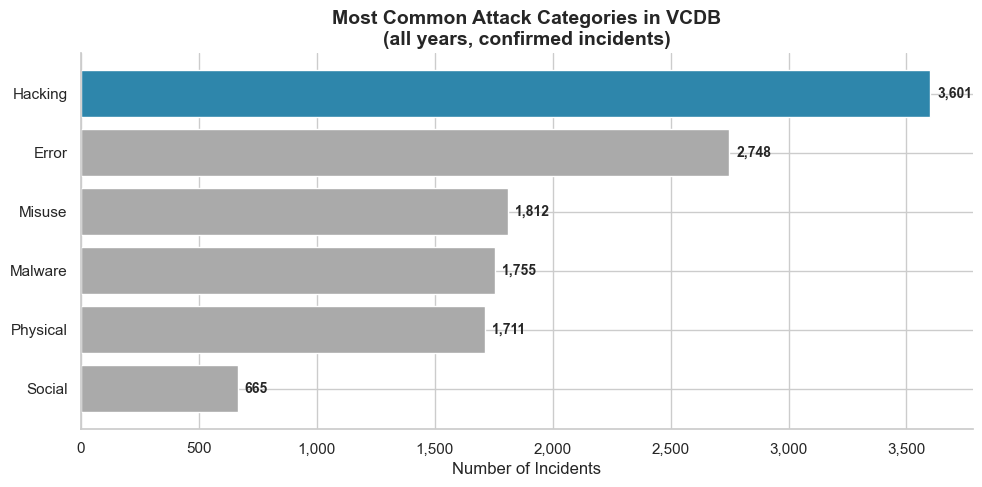

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = [BLUE if v == category_series.max() else GRAY
          for v in category_series.values]

bars = ax.barh(category_series.index, category_series.values,
               color=colors, edgecolor='white')

for bar, val in zip(bars, category_series.values):
    ax.text(val + 30, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va='center', fontsize=10, fontweight='bold')

ax.set_title("Most Common Attack Categories in VCDB\n(all years, confirmed incidents)",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Number of Incidents")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("s2_chart1_categories.png", dpi=150)
plt.show()

External attackers get the headlines, but internal human error is nearly as common a root cause in confirmed breach investigations. Cybersecurity is not just a technology problem — it's a people and process problem.

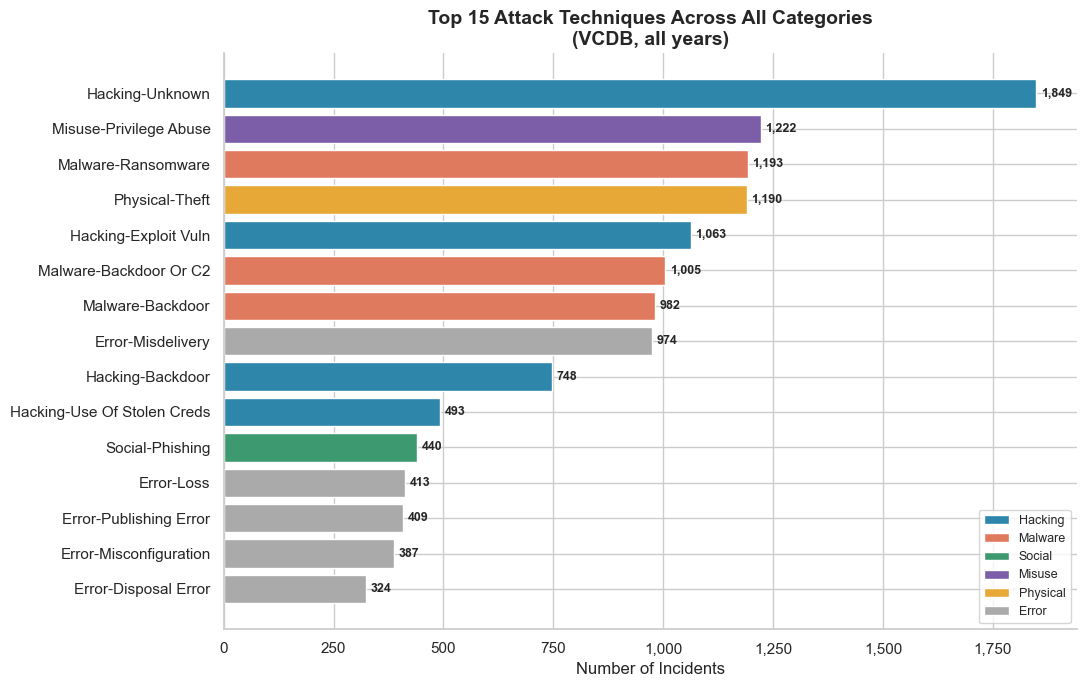

In [37]:
# Color-code by parent category
top_techniques.index = top_techniques.index.str.replace(' — ', '-', regex=False).str.title()
category_color_map = {
    'hacking': BLUE,
    'malware': ORANGE,
    'social':  GREEN,
    'misuse':  PURPLE,
    'physical': "#E8A838",
    'error':   GRAY
}

bar_colors = []
for label in top_techniques.index:
    matched = GRAY
    for cat, color in category_color_map.items():
        if label.lower().startswith(cat):
            matched = color
            break
    bar_colors.append(matched)

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top_techniques.index[::-1], top_techniques.values[::-1],
               color=bar_colors[::-1], edgecolor='white')

for bar, val in zip(bars, top_techniques.values[::-1]):
    ax.text(val + 10, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va='center', fontsize=9, fontweight='bold')

ax.set_title("Top 15 Attack Techniques Across All Categories\n(VCDB, all years)",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Number of Incidents")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Legend for category colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=cat.capitalize())
                   for cat, c in category_color_map.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig("s2_chart2_techniques.png", dpi=150)
plt.show()

The single most common entry in the dataset is 'Unknown'  meaning in nearly 1,900 confirmed breaches, investigators couldn't determine exactly how attackers got in. That's a detection and forensics gap as much as it is an attack problem. Among known methods, privilege abuse and ransomware lead.

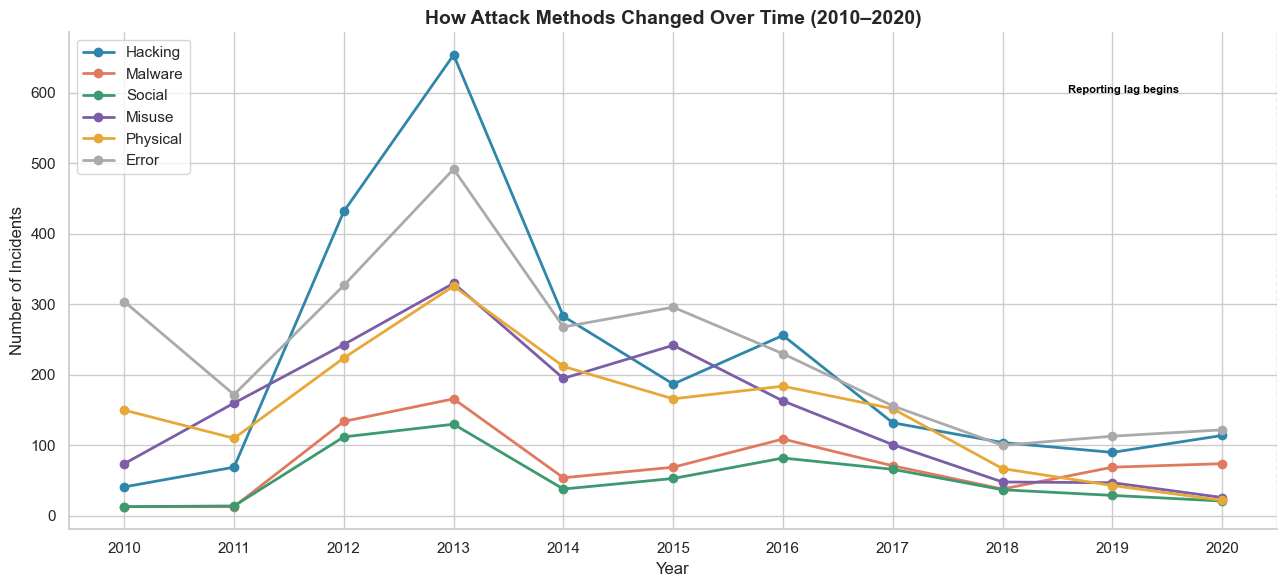

In [38]:
plt.figure(figsize=(13, 6))
for col, color in zip(trend_df.columns, area_colors):
    plt.plot(trend_df.index, trend_df[col], marker='o', linewidth=2, label=col, color=color)

plt.title("How Attack Methods Changed Over Time (2010–2020)", fontsize=14, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Number of Incidents")
plt.xticks(trend_df.index)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.axvline(x=2020.5, color=GRAY, linewidth=1, linestyle="--")
plt.text(2018.6, 600, "Reporting lag begins", fontsize=8, color='Black', fontweight = 'bold')
plt.legend()
plt.tight_layout()
plt.savefig("s2_chart3_trends.png", dpi=150)
plt.show()

The early 2010s were defined by physical and human-error incidents. The mid-2010s mark a turning point where digital hacking overtook everything else. This shift coincides with the professionalization of cybercrime and the rise of ransomware-as-a-service.

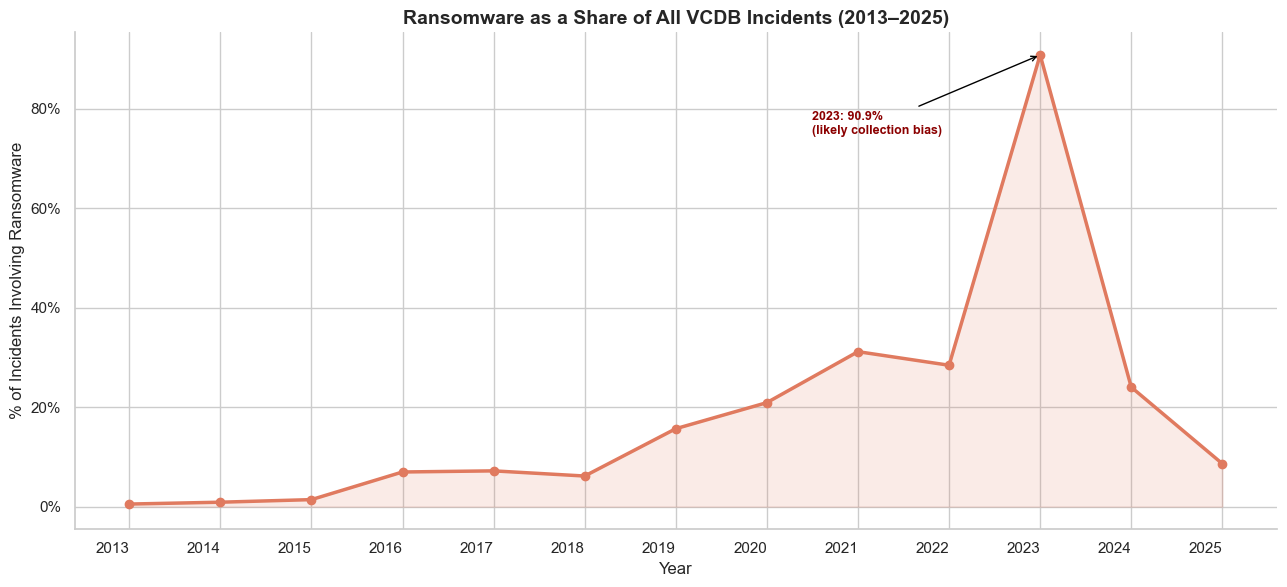

In [39]:
# Drop 2023 outlier for the main line, annotate it separately
ransom_pct = vcdb_ransom_pct[
    (vcdb_ransom_pct.index >= 2013) & (vcdb_ransom_pct.index <= 2025)
]

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(ransom_pct.index, ransom_pct.values,
        color=ORANGE, marker='o', linewidth=2.5, label='Ransomware % of all incidents')
ax.fill_between(ransom_pct.index, ransom_pct.values, alpha=0.15, color=ORANGE)

# Flag the 2023 spike as anomalous
ax.annotate("2023: 90.9%\n(likely collection bias)",
            xy=(2023, ransom_pct[2023]),
            xytext=(2020.5, 75),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=9, fontweight='bold', color='darkred')

ax.set_title("Ransomware as a Share of All VCDB Incidents (2013–2025)",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("% of Incidents Involving Ransomware")
ax.set_xticks(ransom_pct.index)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.set_xticklabels(ransom_pct.index, ha='right')
plt.tight_layout()
plt.savefig("s2_chart4_ransomware.png", dpi=150)
plt.show()

Ransomware grew from a niche threat to accounting for roughly one in three confirmed breaches by 2021. The 2023 figure is an artifact of how VCDB collected data that year — not a real-world rate — which is why we flag it explicitly.

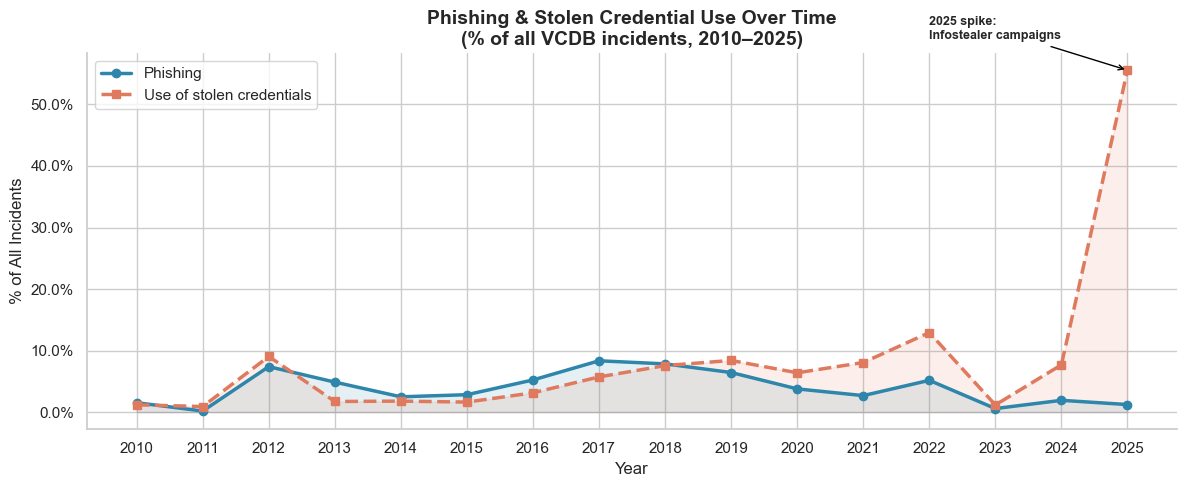

In [40]:
phish_pct  = vcdb_phish_pct[(vcdb_phish_pct.index >= 2010) & (vcdb_phish_pct.index <= 2025)]
creds_pct  = (vcdb_creds / vcdb.groupby(year_col).size() * 100)
creds_pct  = creds_pct[(creds_pct.index >= 2010) & (creds_pct.index <= 2025)]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(phish_pct.index, phish_pct.values,
        color=BLUE, marker='o', linewidth=2.5, label='Phishing')
ax.fill_between(phish_pct.index, phish_pct.values, alpha=0.12, color=BLUE)

ax.plot(creds_pct.index, creds_pct.values,
        color=ORANGE, marker='s', linewidth=2.5, linestyle='--',
        label='Use of stolen credentials')
ax.fill_between(creds_pct.index, creds_pct.values, alpha=0.12, color=ORANGE)

# Annotate 2025 stolen creds spike
ax.annotate("2025 spike:\nInfostealer campaigns",
            xy=(2025, creds_pct[2025]),
            xytext=(2022, creds_pct[2025] + 5),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=9, fontweight='bold')

ax.set_title("Phishing & Stolen Credential Use Over Time\n(% of all VCDB incidents, 2010–2025)",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("% of All Incidents")
ax.set_xticks(phish_pct.index)
ax.tick_params(axis='x')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
ax.legend()

plt.tight_layout()
plt.savefig("s2_chart5_phishing_creds.png", dpi=150)
plt.show()

Phishing and credential theft are two stages of the same attack chain. Phishing harvests credentials; stolen credentials enable network intrusion. The sharp 2025 spike in credential use reflects a documented surge in infostealer malware campaigns that made valid credentials cheap and abundant for attackers

Summary

How are attackers getting in? The data from VCDB gives a pretty clear picture across more than a decade of confirmed incidents.

Hacking is the most common way attackers gain access, showing up in over 3,600 incidents. What is surprising is that human error comes in second, ahead of malware, physical theft, and social engineering. That means a meaningful share of breaches are not the result of sophisticated attacks at all. Somebody sent a file to the wrong person, left a database misconfigured, or accidentally published sensitive data. The attacker did not even have to try.

When you look at individual techniques, privilege abuse by insiders and ransomware sit near the top alongside hacking unknowns and vulnerability exploitation. Phishing shows up at around 440 confirmed incidents, which understates its real-world frequency since VCDB only captures phishing attempts that actually led to a breach.

The trend data from 2010 to 2020 tells a story of escalation. Hacking and malware both grew significantly through 2013 and have remained elevated since. Physical theft, which was a major concern in the early part of that window, declined steadily as the threat landscape shifted to digital intrusion.

Ransomware is the standout trend. It was essentially nonexistent before 2013 and accounted for less than 2 percent of incidents through 2015. By 2020 it had climbed to about 21 percent, and by 2021 it was nearly a third of all VCDB incidents. The 2023 figure of 91 percent is flagged in the chart as likely reflecting a collection bias rather than a true real-world rate, since VCDB appeared to capture mostly ransomware cases that year.

Phishing peaked as a share of breaches around 2017 and 2018, then appears to decline. This is partly the reporting lag issue and partly the fact that VCDB only captures successful breach outcomes. Phishing did not stop growing in the real world. What changed is that VCDB's coverage thinned out in recent years.

Credential theft rounds out the picture. Use of stolen credentials has been a consistent feature of the breach landscape throughout the decade, and the spike in 2025 is notable. It likely reflects the maturation of infostealer malware as a service, where credentials are harvested at scale and sold for use in follow-on intrusions.

The overall takeaway is that attackers are using a mix of technical exploitation, social manipulation, and purchased credentials to get in, and ransomware has become the dominant threat type in the confirmed breach record.